In [4]:
%%capture
!pip install pandas matplotlib

In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

RUN_DIR = Path("/opt/ls/agentic_kv_bench/runs/qwen3-8b-awq_lmcache_sweep_20260724/c008/amoprof")
# Set to None to plot every cycle; or a glob like "service_cycle_20260724_2048*"
CYCLE_GLOB = "service_cycle_*"


In [2]:
def flatten(d, prefix=""):
    out = {}
    for k, v in d.items():
        key = f"{prefix}.{k}" if prefix else k
        if isinstance(v, dict):
            out.update(flatten(v, key))
        elif isinstance(v, list):
            # skip lists (per-gpu arrays etc.) — not needed for these plots
            continue
        else:
            out[key] = v
    return out

rows = []
for cycle_dir in sorted(RUN_DIR.glob(CYCLE_GLOB)):
    sfile = cycle_dir / "summary.json"
    if not sfile.exists():
        continue
    with open(sfile) as f:
        data = json.load(f)
    flat = flatten(data.get("summary", {}))
    flat["cycle"]     = cycle_dir.name
    flat["t0_epoch"]  = data.get("meta", {}).get("t0_epoch")
    flat["timestamp"] = pd.to_datetime(data.get("meta", {}).get("start_time_utc"))
    rows.append(flat)

df = pd.DataFrame(rows).sort_values("timestamp").reset_index(drop=True)
df["cycle_idx"] = range(len(df))
print(f"Loaded {len(df)} cycles, {df.shape[1]} columns")
df.head()


Loaded 559 cycles, 185 columns


,biosnoop.biosnoop_available,biosnoop.biosnoop_events,biosnoop.biosnoop_events_all_devices,biosnoop.biosnoop_csv,biosnoop.biosnoop_all_devices_csv,biosnoop.biosnoop_summary,biosnoop.biosnoop_duration_s,biosnoop.biosnoop_filter_disk,biosnoop.collection_start_time_seconds,biosnoop.collection_end_time_seconds,...,vmstat.hugepages_free,vmstat.hugepages_used,vmstat.hugepage_size_kb,vmstat.collection_start_time_seconds,vmstat.collection_end_time_seconds,vmstat.collection_duration_s,cycle,t0_epoch,timestamp,cycle_idx
0,True,37,86,/opt/ls/agentic_kv_bench/runs/qwen3-8b-awq_lmc...,/opt/ls/agentic_kv_bench/runs/qwen3-8b-awq_lmc...,/opt/ls/agentic_kv_bench/runs/qwen3-8b-awq_lmc...,11.06,nvme1n1,1.784926e+09,1.784926e+09,...,0,0,2048,1.784926e+09,1.784926e+09,10.833815,service_cycle_20260724_204738,1.784926e+09,2026-07-24 20:47:38.084137+00:00,0
1,True,1849,1866,/opt/ls/agentic_kv_bench/runs/qwen3-8b-awq_lmc...,/opt/ls/agentic_kv_bench/runs/qwen3-8b-awq_lmc...,/opt/ls/agentic_kv_bench/runs/qwen3-8b-awq_lmc...,10.94,nvme1n1,1.784926e+09,1.784926e+09,...,0,0,2048,1.784926e+09,1.784926e+09,10.674761,service_cycle_20260724_204750,1.784926e+09,2026-07-24 20:47:50.655455+00:00,1
2,True,4474,4508,/opt/ls/agentic_kv_bench/runs/qwen3-8b-awq_lmc...,/opt/ls/agentic_kv_bench/runs/qwen3-8b-awq_lmc...,/opt/ls/agentic_kv_bench/runs/qwen3-8b-awq_lmc...,10.92,nvme1n1,1.784926e+09,1.784926e+09,...,0,0,2048,1.784926e+09,1.784926e+09,10.673718,service_cycle_20260724_204803,1.784926e+09,2026-07-24 20:48:03.754832+00:00,2
3,True,4157,4192,/opt/ls/agentic_kv_bench/runs/qwen3-8b-awq_lmc...,/opt/ls/agentic_kv_bench/runs/qwen3-8b-awq_lmc...,/opt/ls/agentic_kv_bench/runs/qwen3-8b-awq_lmc...,10.88,nvme1n1,1.784926e+09,1.784926e+09,...,0,0,2048,1.784926e+09,1.784926e+09,10.663616,service_cycle_20260724_204816,1.784926e+09,2026-07-24 20:48:16.276325+00:00,3
4,True,3798,3815,/opt/ls/agentic_kv_bench/runs/qwen3-8b-awq_lmc...,/opt/ls/agentic_kv_bench/runs/qwen3-8b-awq_lmc...,/opt/ls/agentic_kv_bench/runs/qwen3-8b-awq_lmc...,11.11,nvme1n1,1.784926e+09,1.784926e+09,...,0,0,2048,1.784926e+09,1.784926e+09,10.861849,service_cycle_20260724_204828,1.784926e+09,2026-07-24 20:48:28.785067+00:00,4


In [3]:
def plot_metric(cols, title, ylabel, ax_x="cycle_idx"):
    fig, ax = plt.subplots(figsize=(10, 3.5))
    for c in cols:
        if c in df.columns:
            ax.plot(df[ax_x], df[c], marker="o", markersize=3, label=c)
        else:
            print(f"  [skip] {c} not in df")
    ax.set_title(title)
    ax.set_xlabel("cycle index (time-ordered)")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    if len(cols) > 1:
        ax.legend(fontsize=8, loc="best")
    plt.tight_layout()
    plt.show()


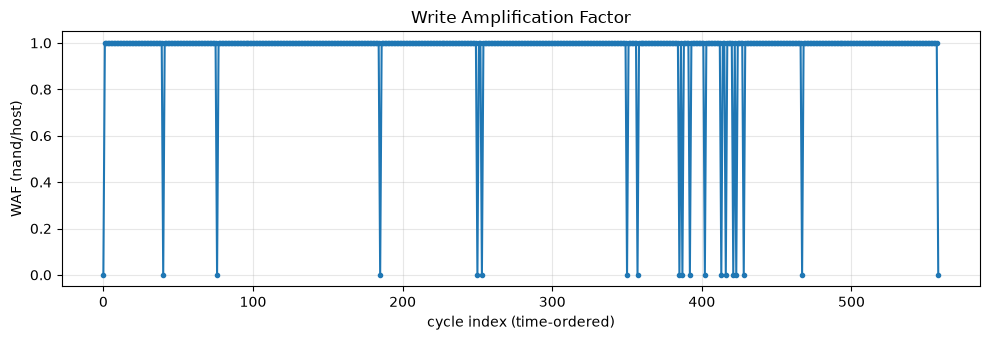

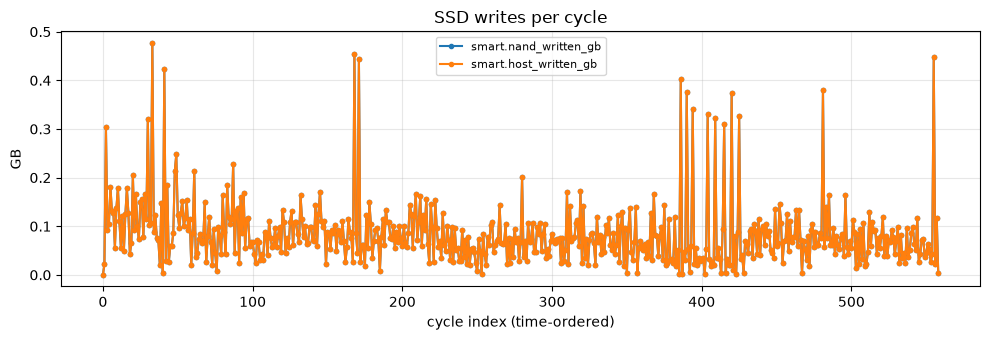

In [4]:
plot_metric(["smart.waf"],                "Write Amplification Factor", "WAF (nand/host)")
plot_metric(["smart.nand_written_gb",
             "smart.host_written_gb"],    "SSD writes per cycle",       "GB")

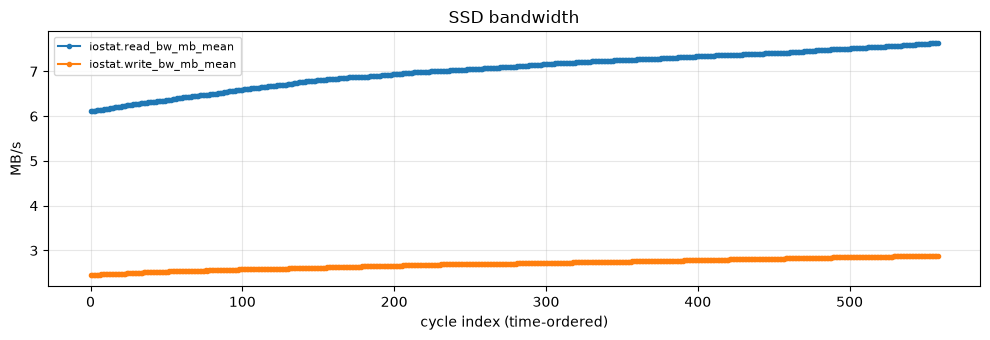

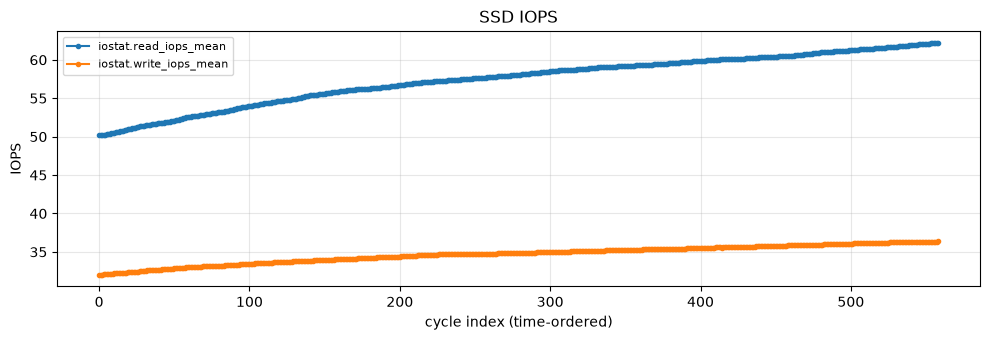

In [5]:
plot_metric(["iostat.read_bw_mb_mean",
             "iostat.write_bw_mb_mean"],  "SSD bandwidth",              "MB/s")
plot_metric(["iostat.read_iops_mean",
             "iostat.write_iops_mean"],   "SSD IOPS",                   "IOPS")

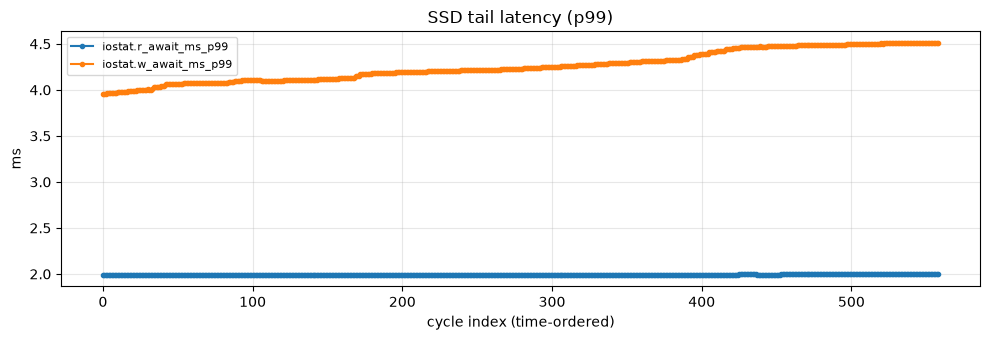

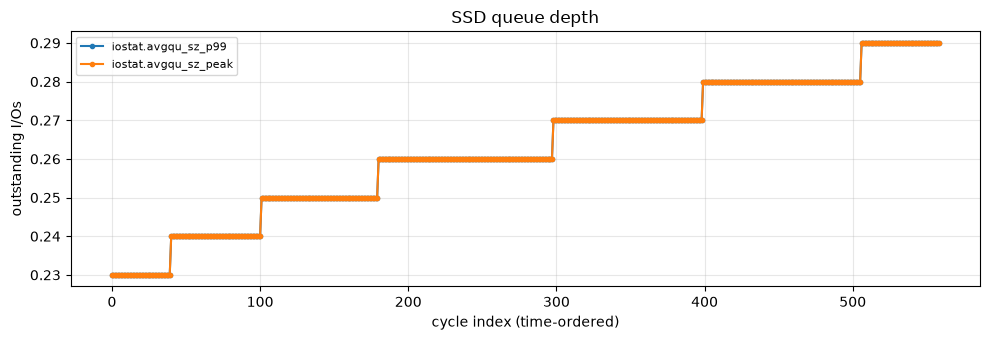

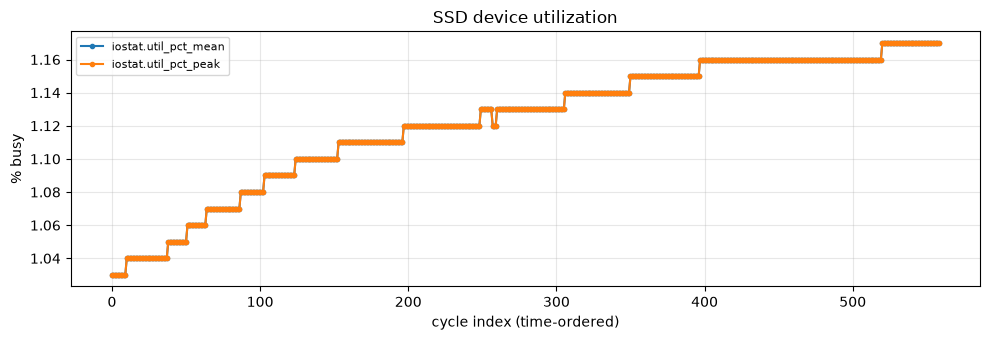

In [6]:
plot_metric(["iostat.r_await_ms_p99",
             "iostat.w_await_ms_p99"],    "SSD tail latency (p99)",     "ms")
plot_metric(["iostat.avgqu_sz_p99",
             "iostat.avgqu_sz_peak"],     "SSD queue depth",            "outstanding I/Os")
plot_metric(["iostat.util_pct_mean",
             "iostat.util_pct_peak"],     "SSD device utilization",     "% busy")

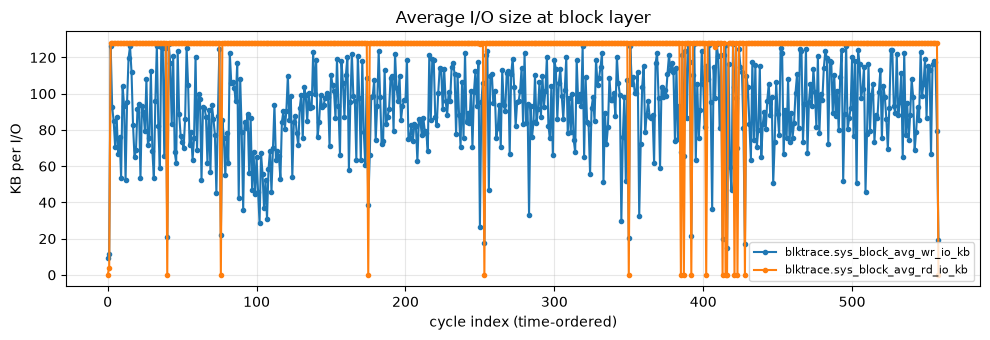

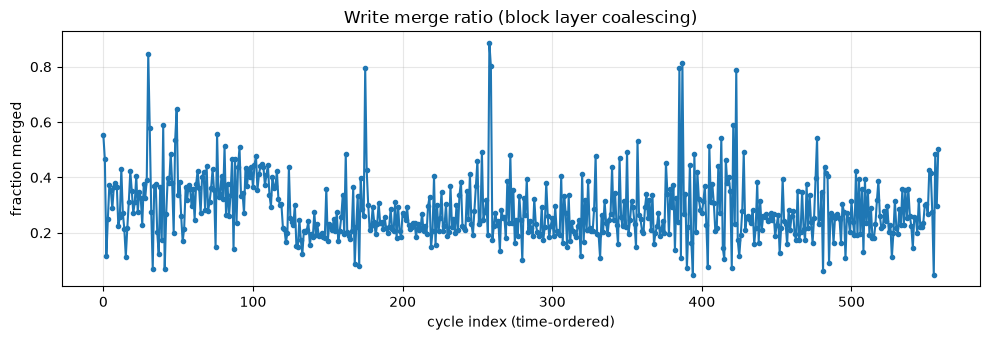

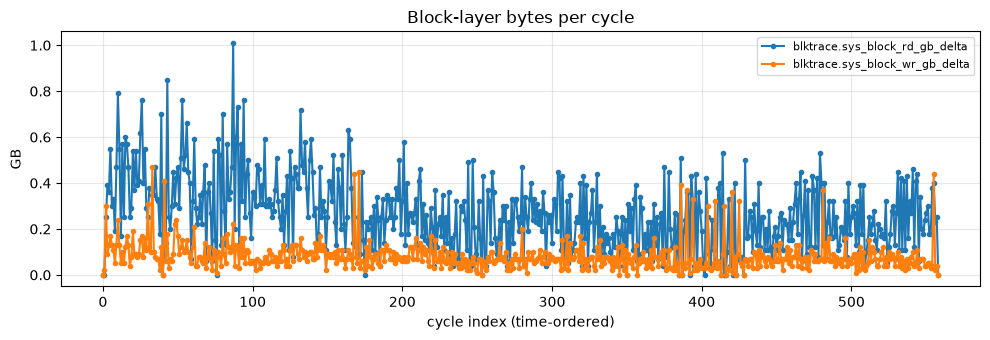

In [7]:
plot_metric(["blktrace.sys_block_avg_wr_io_kb",
             "blktrace.sys_block_avg_rd_io_kb"],
            "Average I/O size at block layer",  "KB per I/O")
plot_metric(["blktrace.sys_block_wr_merge_ratio"],
            "Write merge ratio (block layer coalescing)", "fraction merged")
plot_metric(["blktrace.sys_block_rd_gb_delta",
             "blktrace.sys_block_wr_gb_delta"],
            "Block-layer bytes per cycle",      "GB")

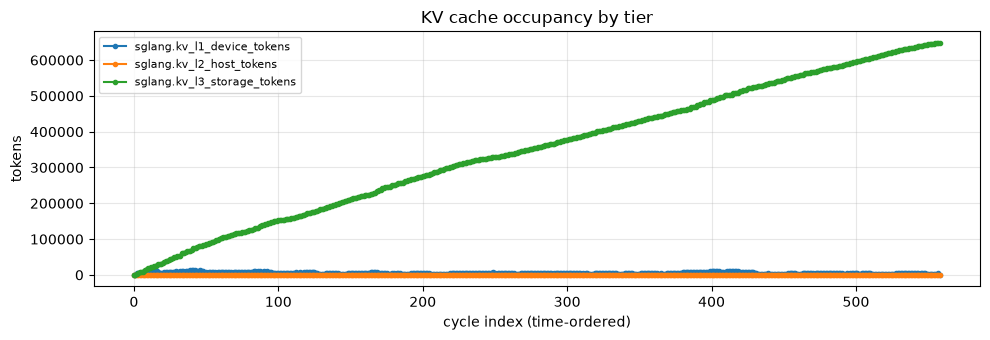

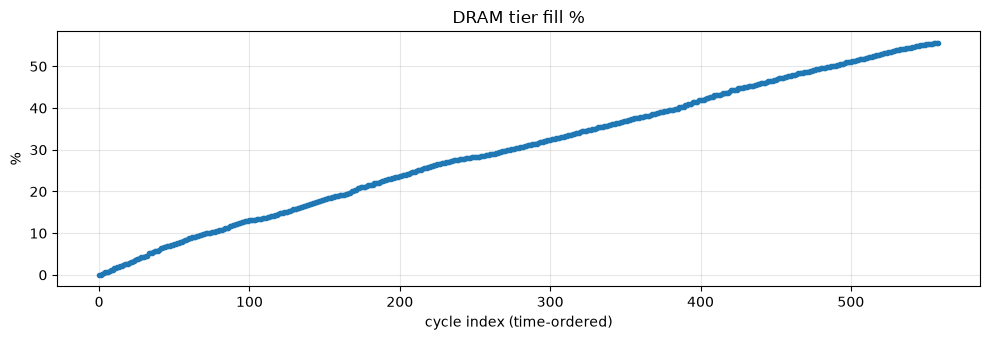

In [8]:
plot_metric(["sglang.kv_l1_device_tokens",
             "sglang.kv_l2_host_tokens",
             "sglang.kv_l3_storage_tokens"],
            "KV cache occupancy by tier",        "tokens")
plot_metric(["sglang.hicache_host_fill_pct"],
            "DRAM tier fill %",                  "%")

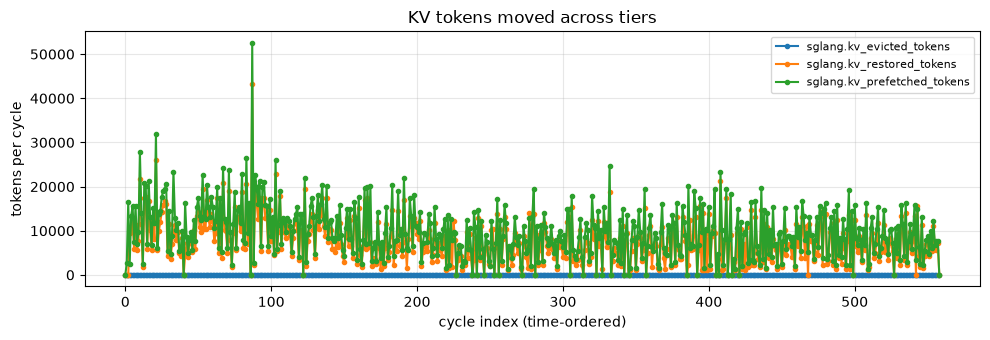

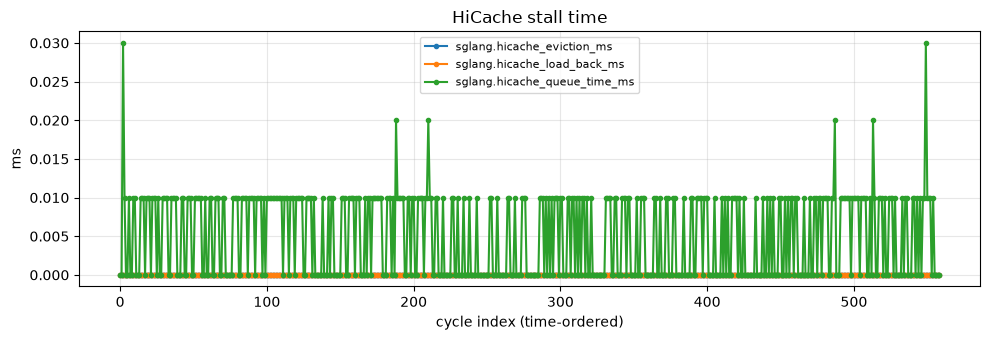

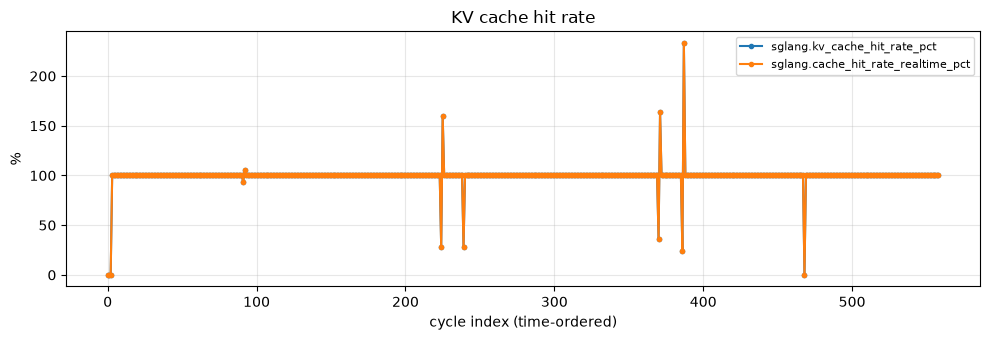

In [9]:
plot_metric(["sglang.kv_evicted_tokens",
             "sglang.kv_restored_tokens",
             "sglang.kv_prefetched_tokens"],
            "KV tokens moved across tiers",      "tokens per cycle")
plot_metric(["sglang.hicache_eviction_ms",
             "sglang.hicache_load_back_ms",
             "sglang.hicache_queue_time_ms"],
            "HiCache stall time",                "ms")
plot_metric(["sglang.kv_cache_hit_rate_pct",
             "sglang.cache_hit_rate_realtime_pct"],
            "KV cache hit rate",                 "%")

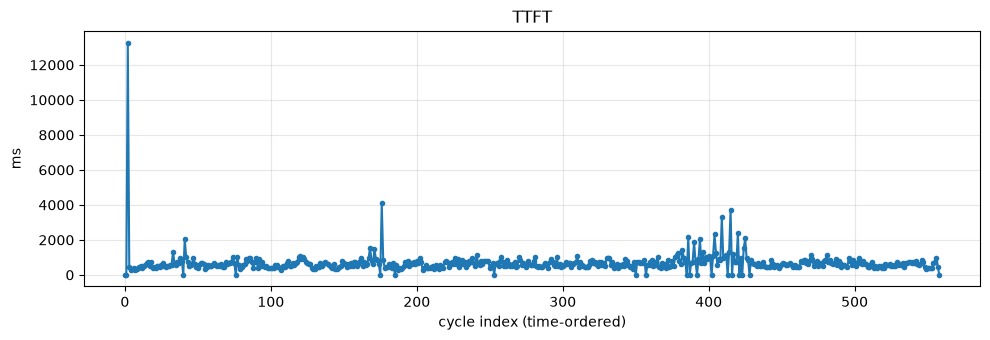

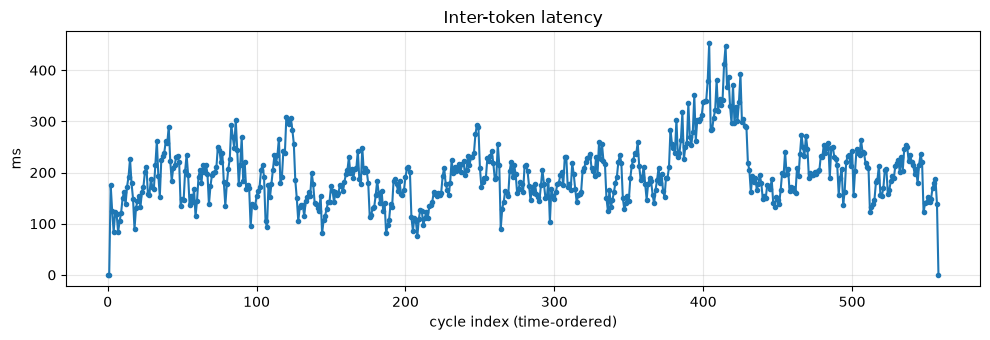

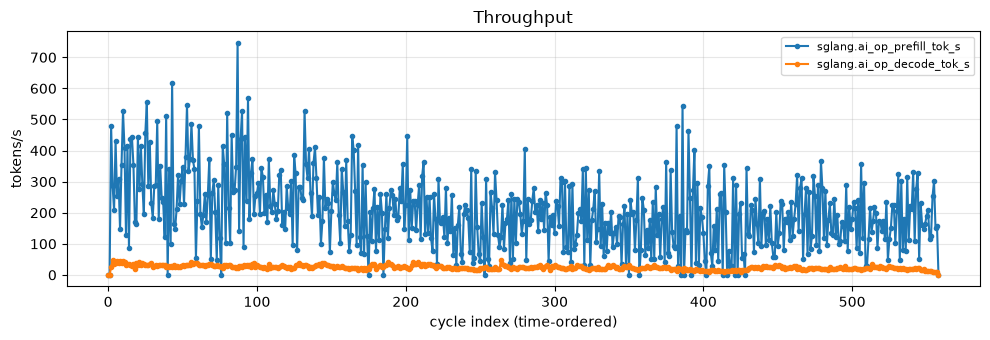

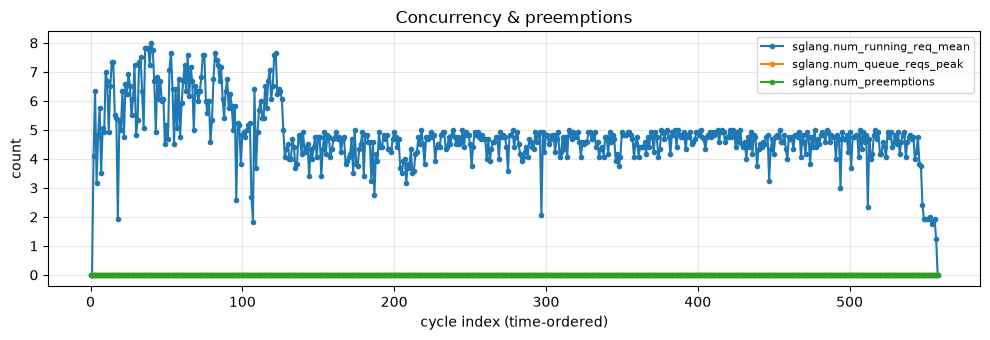

In [10]:
plot_metric(["sglang.server_ttft_ms"],   "TTFT",                       "ms")
plot_metric(["sglang.server_itl_ms"],    "Inter-token latency",        "ms")
plot_metric(["sglang.ai_op_prefill_tok_s",
             "sglang.ai_op_decode_tok_s"],
            "Throughput",                        "tokens/s")
plot_metric(["sglang.num_running_req_mean",
             "sglang.num_queue_reqs_peak",
             "sglang.num_preemptions"],
            "Concurrency & preemptions",         "count")

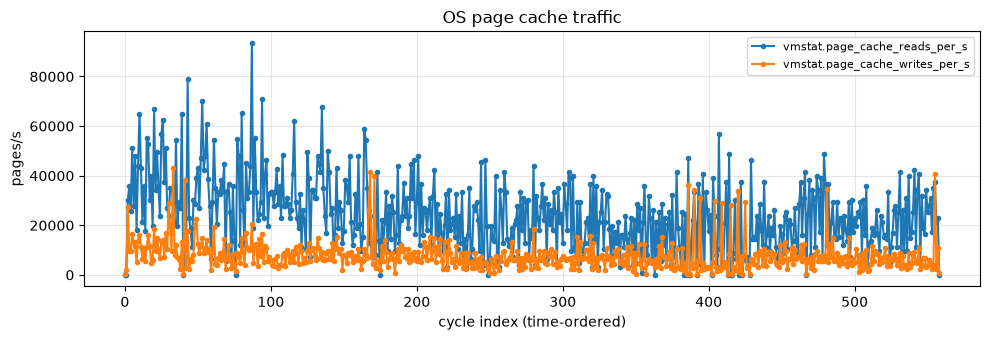

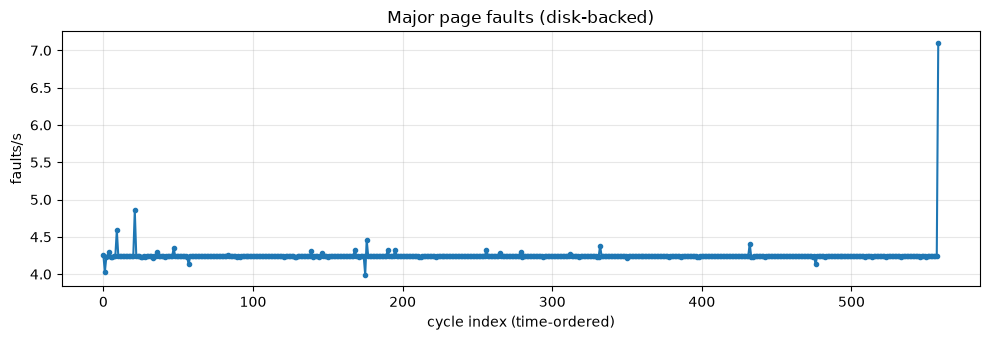

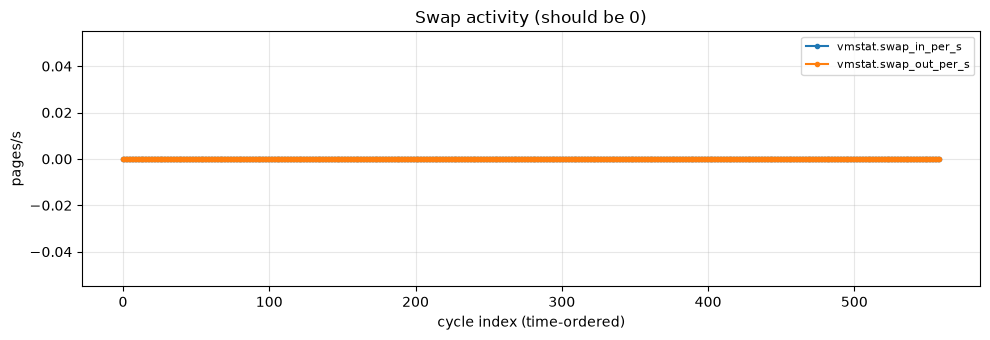

In [11]:
plot_metric(["vmstat.page_cache_reads_per_s",
             "vmstat.page_cache_writes_per_s"],
            "OS page cache traffic",             "pages/s")
plot_metric(["vmstat.major_faults_per_s"],
            "Major page faults (disk-backed)",   "faults/s")
plot_metric(["vmstat.swap_in_per_s",
             "vmstat.swap_out_per_s"],
            "Swap activity (should be 0)",       "pages/s")


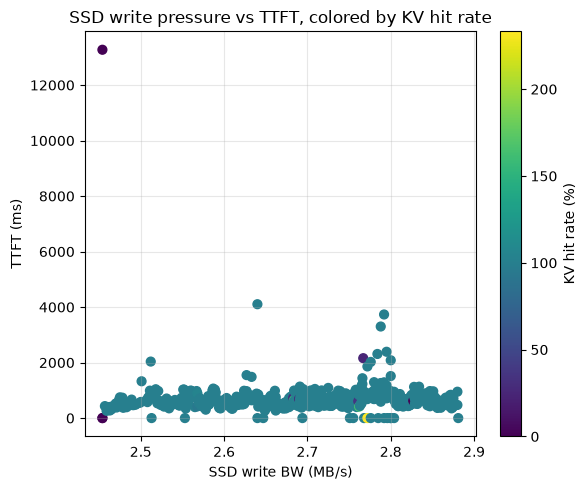

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(df["iostat.write_bw_mb_mean"],
                df["sglang.server_ttft_ms"],
                c=df["sglang.kv_cache_hit_rate_pct"],
                cmap="viridis", s=40)
ax.set_xlabel("SSD write BW (MB/s)")
ax.set_ylabel("TTFT (ms)")
ax.set_title("SSD write pressure vs TTFT, colored by KV hit rate")
plt.colorbar(sc, label="KV hit rate (%)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
